# 08 — Model Evaluation

## Objective

This notebook performs a detailed evaluation of the selected machine learning model for predicting `company_response_to_consumer`.

The final model was selected during the modeling phase after comparing multiple classification algorithms using imbalance-aware evaluation metrics.

This notebook focuses on:

- Overall model performance
- Per-class precision, recall, and F1-score
- Confusion matrix analysis
- Generalization performance
- Feature importance
- Model limitations
- Final evaluation conclusions

The primary evaluation metrics are **Macro F1** and **Balanced Accuracy**, since the target classes are highly imbalanced.

In [1]:
from google.colab import drive

drive.mount("/content/drive")

Mounted at /content/drive


In [29]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    f1_score,
    precision_score,
    recall_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [30]:
# Load model-ready test data

processed_path = "/content/drive/MyDrive/Consumer Complain Project/data/processed"

X_test = pd.read_parquet(f"{processed_path}/X_test.parquet")
y_test = pd.read_parquet(f"{processed_path}/y_test.parquet")

print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_test shape: (12968, 262)
y_test shape: (12968, 1)


In [31]:
# Load the selected model

import joblib

model_path = f"{processed_path}/hist_gradient_boosting_model.joblib"

model = joblib.load(model_path)

print("Model loaded:", type(model).__name__)

Model loaded: HistGradientBoostingClassifier


In [32]:
# Generate predictions on the unseen test set

y_pred = model.predict(X_test)

print("Predictions generated successfully.")
print("Number of predictions:", len(y_pred))

Predictions generated successfully.
Number of predictions: 12968


In [33]:
# Calculate overall evaluation metrics
y_true = y_test.iloc[:, 0]
accuracy = accuracy_score(y_test, y_pred)
balanced_accuracy = balanced_accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {accuracy:.4f}")
print(f"Balanced Accuracy: {balanced_accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

Accuracy: 0.6769
Balanced Accuracy: 0.8309
Macro F1: 0.5074


In [34]:
# Detailed per-class evaluation

class_report = classification_report(
    y_test,
    y_pred,
    output_dict=True
)

class_report_df = pd.DataFrame(class_report).T

class_report_df

,precision,recall,f1-score,support
Closed with explanation,0.971781,0.619666,0.756770,10170.000000
Closed with monetary relief,0.180617,0.911111,0.301471,315.000000
Closed with non-monetary relief,0.468156,0.880252,0.611233,2380.000000
Untimely response,0.224344,0.912621,0.360153,103.000000
accuracy,0.676897,0.676897,0.676897,0.676897
macro avg,0.461224,0.830913,0.507407,12968.000000
weighted avg,0.854197,0.676897,0.715850,12968.000000


In [35]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=model.classes_)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[6302 1184 2378  306]
 [  20  287    2    6]
 [ 158  114 2095   13]
 [   5    4    0   94]]


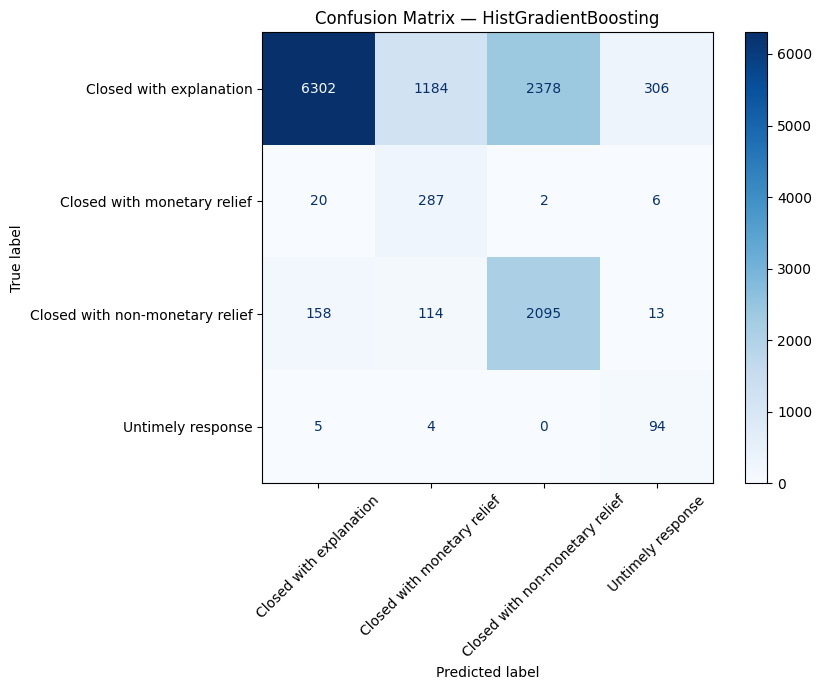

In [36]:
# Visualize the confusion matrix

class_names = model.classes_

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
).plot(
    ax=ax,
    xticks_rotation=45,
    cmap="Blues"
)

ax.set_title("Confusion Matrix — HistGradientBoosting")
plt.tight_layout()
plt.show()

In [37]:
# Compare actual and predicted class distributions

actual_distribution = y_test.iloc[:, 0].value_counts().rename("Actual")
predicted_distribution = pd.Series(y_pred).value_counts().rename("Predicted")

distribution_comparison = pd.concat(
    [actual_distribution, predicted_distribution],
    axis=1
).fillna(0)

distribution_comparison["Actual"] = distribution_comparison["Actual"].astype(int)
distribution_comparison["Predicted"] = distribution_comparison["Predicted"].astype(int)

distribution_comparison

,Actual,Predicted
Closed with explanation,10170,6485
Closed with non-monetary relief,2380,4475
Closed with monetary relief,315,1589
Untimely response,103,419


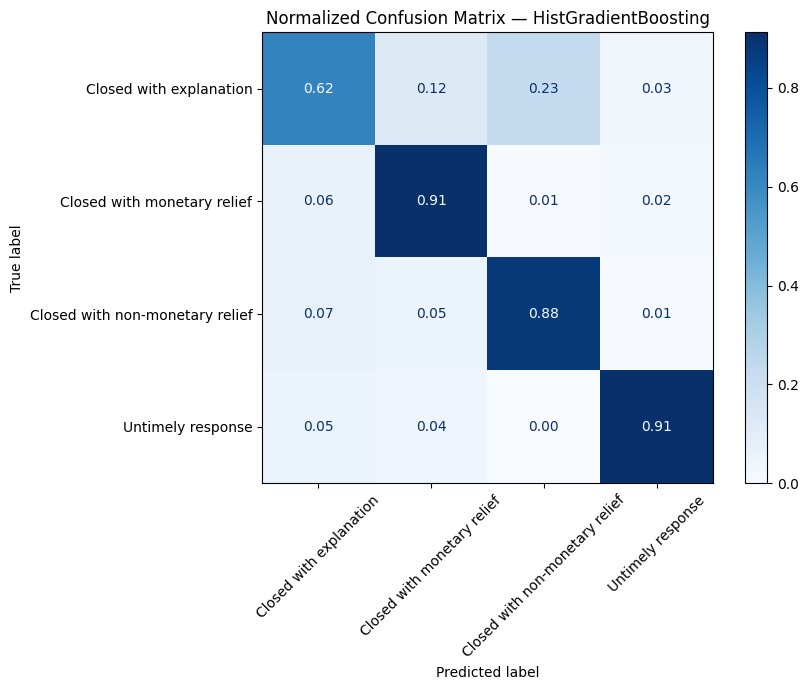

In [38]:
# Normalized confusion matrix

cm_normalized = confusion_matrix(
    y_test,
    y_pred,
    normalize="true"
)

fig, ax = plt.subplots(figsize=(9, 7))

ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=class_names
).plot(
    ax=ax,
    xticks_rotation=45,
    values_format=".2f",
    cmap="Blues"
)

ax.set_title("Normalized Confusion Matrix — HistGradientBoosting")
plt.tight_layout()
plt.show()

In [39]:
# Compare training and test Macro F1

y_train_pred = model.predict(
    pd.read_parquet(f"{processed_path}/X_train.parquet")
)

train_macro_f1 = f1_score(
    pd.read_parquet(f"{processed_path}/y_train.parquet").iloc[:, 0],
    y_train_pred,
    average="macro"
)

test_macro_f1 = f1_score(
    y_test.iloc[:, 0],
    y_pred,
    average="macro"
)

print(f"Training Macro F1: {train_macro_f1:.4f}")
print(f"Test Macro F1: {test_macro_f1:.4f}")
print(f"Generalization Gap: {train_macro_f1 - test_macro_f1:.4f}")

Training Macro F1: 0.5360
Test Macro F1: 0.5074
Generalization Gap: 0.0286


In [40]:
# Check feature importance support

has_feature_importance = hasattr(model, "feature_importances_")

print("Has feature_importances_:", has_feature_importance)

Has feature_importances_: False


In [41]:
from sklearn.inspection import permutation_importance

# Calculate permutation importance on the test set

perm_importance = permutation_importance(
    model,
    X_test,
    y_test.iloc[:, 0],
    scoring="f1_macro",
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

feature_importance_df = pd.DataFrame({
    "feature": X_test.columns,
    "importance_mean": perm_importance.importances_mean,
    "importance_std": perm_importance.importances_std
}).sort_values(
    "importance_mean",
    ascending=False
)

feature_importance_df.head(20)

,feature,importance_mean,importance_std
9,company_frequency,0.218273,0.006060
1,received_month,0.049619,0.002168
3,received_day,0.037013,0.002228
12,product_Credit reporting or other personal con...,0.009882,0.003865
7,narrative_length,0.003770,0.000726
0,received_year,0.003011,0.000298
22,sub_product_Checking account,0.002371,0.000579
45,sub_product_Other debt,0.001914,0.000337
6,narrative_present,0.001865,0.000942
13,product_Debt collection,0.001730,0.000777


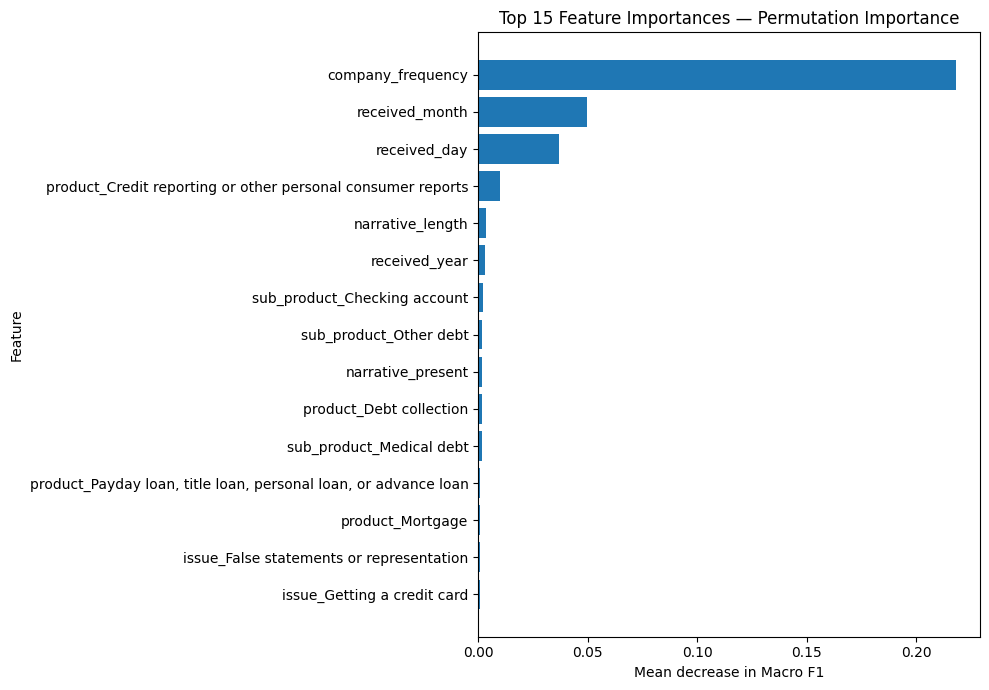

In [42]:
# Visualize the top 15 permutation importances

top_features = feature_importance_df.head(15).sort_values(
    "importance_mean"
)

plt.figure(figsize=(10, 7))

plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Mean decrease in Macro F1")
plt.ylabel("Feature")
plt.title("Top 15 Feature Importances — Permutation Importance")

plt.tight_layout()
plt.show()

In [43]:
# Check stability of the top feature importances

top_features_stability = feature_importance_df.head(15).copy()

top_features_stability[
    ["feature", "importance_mean", "importance_std"]
]

,feature,importance_mean,importance_std
9,company_frequency,0.218273,0.006060
1,received_month,0.049619,0.002168
3,received_day,0.037013,0.002228
12,product_Credit reporting or other personal con...,0.009882,0.003865
7,narrative_length,0.003770,0.000726
0,received_year,0.003011,0.000298
22,sub_product_Checking account,0.002371,0.000579
45,sub_product_Other debt,0.001914,0.000337
6,narrative_present,0.001865,0.000942
13,product_Debt collection,0.001730,0.000777


## Evaluation Summary

The selected HistGradientBoosting model achieved the following performance on the unseen test set:

- **Accuracy:** 0.6769
- **Balanced Accuracy:** 0.8309
- **Macro F1:** 0.5074

The model achieved high recall for the minority classes, including:

- **Closed with monetary relief:** 0.91
- **Closed with non-monetary relief:** 0.88
- **Untimely response:** 0.91

However, precision for these classes was lower, indicating that the model also assigns some majority-class observations to minority classes.

The normalized confusion matrix shows that the largest source of error is confusion between **Closed with explanation** and **Closed with non-monetary relief**.

The training Macro F1 was **0.5360**, compared with **0.5074** on the test set, giving a generalization gap of **0.0286**.

Permutation importance identified **company_frequency** as the most influential feature, followed by **received_month** and **received_day**. These results indicate predictive association, not causation.

Overall, the evaluation shows that the model generalizes to unseen data and is substantially more informative across classes than the majority-class baseline. However, the relatively low Macro F1 and class-level precision indicate that there is still room for improvement.

In [44]:
# Identify correctly and incorrectly classified observations

correct_predictions = (y_test.iloc[:, 0].values == y_pred)

correct_count = correct_predictions.sum()
incorrect_count = (~correct_predictions).sum()

print("Correct predictions:", correct_count)
print("Incorrect predictions:", incorrect_count)
print(f"Overall error rate: {incorrect_count / len(y_test):.2%}")

Correct predictions: 8778
Incorrect predictions: 4190
Overall error rate: 32.31%


In [45]:
# Calculate class-wise prediction errors

error_analysis = pd.DataFrame({
    "actual_class": y_test.iloc[:, 0].values,
    "predicted_class": y_pred
})

class_error_summary = (
    error_analysis
    .assign(
        is_error=lambda df: df["actual_class"] != df["predicted_class"]
    )
    .groupby("actual_class")
    .agg(
        total_cases=("actual_class", "size"),
        errors=("is_error", "sum")
    )
)

class_error_summary["error_rate"] = (
    class_error_summary["errors"] /
    class_error_summary["total_cases"]
)

class_error_summary.sort_values(
    "error_rate",
    ascending=False
)

,total_cases,errors,error_rate
actual_class,,,
Closed with explanation,10170,3868,0.380334
Closed with non-monetary relief,2380,285,0.119748
Closed with monetary relief,315,28,0.088889
Untimely response,103,9,0.087379


In [46]:
# Analyze misclassifications for the largest error class
majority_class = error_analysis["actual_class"].value_counts().idxmax()

print("Majority class:", majority_class)

majority_class_errors = (
    error_analysis[
        (error_analysis["actual_class"] == majority_class) &
        (error_analysis["predicted_class"] != majority_class)
    ]
    ["predicted_class"]
    .value_counts()
    .rename_axis("predicted_class")
    .reset_index(name="error_count")
)

majority_class_errors

Majority class: Closed with explanation


,predicted_class,error_count
0,Closed with non-monetary relief,2378
1,Closed with monetary relief,1184
2,Untimely response,306


In [47]:
# Quantify the main confusion pair

class_a = "Closed with explanation"
class_b = "Closed with non-monetary relief"

pair_errors = error_analysis[
    (
        (error_analysis["actual_class"] == class_a) &
        (error_analysis["predicted_class"] == class_b)
    )
    |
    (
        (error_analysis["actual_class"] == class_b) &
        (error_analysis["predicted_class"] == class_a)
    )
]

print("Total confusion between the two classes:", len(pair_errors))

print("\nDirection of confusion:")
print(
    pair_errors
    .groupby(["actual_class", "predicted_class"])
    .size()
    .rename("count")
)

Total confusion between the two classes: 2536

Direction of confusion:
actual_class                     predicted_class                
Closed with explanation          Closed with non-monetary relief    2378
Closed with non-monetary relief  Closed with explanation             158
Name: count, dtype: int64


In [48]:
# Quantify the second major confusion pair

class_a = "Closed with explanation"
class_b = "Closed with monetary relief"

pair_errors = error_analysis[
    (
        (error_analysis["actual_class"] == class_a) &
        (error_analysis["predicted_class"] == class_b)
    )
    |
    (
        (error_analysis["actual_class"] == class_b) &
        (error_analysis["predicted_class"] == class_a)
    )
]

print("Total confusion between the two classes:", len(pair_errors))

print("\nDirection of confusion:")
print(
    pair_errors
    .groupby(["actual_class", "predicted_class"])
    .size()
    .rename("count")
)

Total confusion between the two classes: 1204

Direction of confusion:
actual_class                 predicted_class            
Closed with explanation      Closed with monetary relief    1184
Closed with monetary relief  Closed with explanation          20
Name: count, dtype: int64


In [49]:
# Create a concise error-analysis summary

error_summary = pd.DataFrame({
    "Metric": [
        "Total test cases",
        "Correct predictions",
        "Incorrect predictions",
        "Overall error rate",
        "Explanation → Non-monetary relief",
        "Explanation → Monetary relief",
        "Explanation → Untimely response"
    ],
    "Value": [
        len(y_test),
        correct_count,
        incorrect_count,
        f"{incorrect_count / len(y_test):.2%}",
        2378,
        1184,
        306
    ]
})

error_summary

,Metric,Value
0,Total test cases,12968
1,Correct predictions,8778
2,Incorrect predictions,4190
3,Overall error rate,32.31%
4,Explanation → Non-monetary relief,2378
5,Explanation → Monetary relief,1184
6,Explanation → Untimely response,306


## Error Analysis Findings

The selected model correctly classified **8,778 out of 12,968** test observations, resulting in an overall error rate of **32.31%**.

The largest class-level error rate occurred for **Closed with explanation**, where **3,868 of 10,170 cases (38.03%)** were misclassified.

The main confusion patterns were:

- **2,378** cases of `Closed with explanation` were predicted as `Closed with non-monetary relief`.
- **1,184** cases of `Closed with explanation` were predicted as `Closed with monetary relief`.
- **306** cases of `Closed with explanation` were predicted as `Untimely response`.

The two largest confusion pairs were:

- `Closed with explanation` ↔ `Closed with non-monetary relief`: **2,536 cases**
- `Closed with explanation` ↔ `Closed with monetary relief`: **1,204 cases**

The errors are strongly asymmetric: most of the confusion in these pairs occurs when the actual class is **Closed with explanation**.

These findings suggest that the model has more difficulty distinguishing the majority `Closed with explanation` class from certain alternative response outcomes. This provides a useful direction for future feature engineering, target refinement, and model improvement.

## Model Limitations

Although the selected model provides useful predictive performance, several limitations should be considered.

- The target classes are highly imbalanced, which makes overall accuracy less informative than class-balanced metrics.
- The model achieves high recall for minority classes but relatively low precision, resulting in false positives for these classes.
- The majority class, `Closed with explanation`, has the highest error rate and is frequently confused with other response outcomes.
- The current feature set is based primarily on structured complaint information and engineered date and narrative features. Additional domain-specific features may improve performance.
- `company_frequency` is the most influential feature according to permutation importance. This represents predictive association and should not be interpreted as a causal relationship.
- The model is evaluated on a single held-out test set. Cross-validation could provide a more robust estimate of performance in future iterations.
- The current model is intended as a portfolio-level predictive modeling exercise and should not be treated as a production decision system without further validation, monitoring, and domain-specific evaluation.

## Final Evaluation Conclusion

The HistGradientBoosting model was selected after comparing multiple classification approaches for predicting `company_response_to_consumer`.

On the unseen test set, the model achieved:

- **Accuracy:** 0.6769
- **Balanced Accuracy:** 0.8309
- **Macro F1:** 0.5074

The model achieved strong recall across the minority classes, but precision remained lower for these classes. The confusion matrix showed that most classification errors involved the majority `Closed with explanation` class.

The training and test Macro F1 scores were **0.5360** and **0.5074**, respectively, resulting in a generalization gap of **0.0286**.

Permutation importance identified `company_frequency`, `received_month`, and `received_day` among the most influential features. These results describe predictive association rather than causation.

The evaluation also highlighted an important modeling lesson: a strong overall accuracy score can be misleading when the target distribution is highly imbalanced. Model evaluation should therefore consider multiple metrics and class-level performance rather than relying on accuracy alone.

This project demonstrates an end-to-end workflow:

**Data Auditing → Data Cleaning → EDA → Feature Audit → Feature Engineering → Model Training → Model Evaluation → Error Analysis**

The current model provides a strong baseline for further experimentation. Future work could explore cross-validation, additional feature engineering, alternative target definitions, hyperparameter tuning, and improved handling of class imbalance.